# Project 1 — Regression from Baseline to Advanced Models

This notebook studies a continuous prediction problem using California Housing data. The focus is not only on fitting models, but on understanding baseline performance, model complexity, regularization, nonlinear features, tree-based methods, residual behavior, and fair comparison.

## Theoretical background: how regression models learn continuous values

Regression models estimate a numerical target from input features. A useful way to study regression is to ask three connected questions: **what pattern can the model represent**, **how strongly is that pattern constrained**, and **how well does the learned pattern generalize to unseen data**.

A **dummy regressor** does not learn feature relationships; it predicts a constant such as the mean target value. It is not meant to be good, but it gives a minimum reference level. If a more complex model cannot beat this baseline clearly, either the features are weak, the preprocessing is wrong, or the modeling assumption is unsuitable.

**Linear regression** represents the target as a weighted sum of features. It is fast and interpretable, but it assumes that each feature contributes additively and approximately linearly. When the real relationship is nonlinear, linear regression may show systematic residual patterns. **Polynomial regression** expands the feature space by adding powers and interactions. This increases flexibility, but also increases variance: the model may fit the training data very well while becoming unstable on validation data.

**Ridge, Lasso, and ElasticNet** are regularized linear models. Regularization penalizes large coefficients so that the model becomes less sensitive to noise and multicollinearity. Ridge shrinks coefficients continuously, Lasso can shrink some coefficients exactly to zero, and ElasticNet mixes both behaviors. The important point is that regularization is not only a numerical trick; it changes the effective complexity of the model.

**Decision trees** split the feature space into regions and predict a value within each region. A shallow tree has high bias; a very deep tree may memorize local details. **Random Forests** reduce the variance of individual trees by averaging many trees trained on bootstrap samples and random feature subsets. **Gradient Boosting** builds trees sequentially, where each new tree focuses on errors left by previous trees. This can reduce bias strongly, but the learning rate, number of trees, and tree depth must be controlled carefully.

Throughout this notebook, the main concern is not only which model gives the smallest RMSE, but why that model behaves that way and whether the improvement is reliable.

## Prerequisites

The notebook assumes comfort with pandas, NumPy, basic statistics, train/test splitting, and the basic idea of linear regression. The code is designed to run from top to bottom.

## Problem statement

Given housing and neighborhood-level features, predict the median house value. Because the target is continuous, this is a regression problem.

## Dataset description and source

The California Housing dataset is loaded directly with `sklearn.datasets.fetch_california_housing`. The features are `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, and `Longitude`; the target is `MedHouseVal`.

The notebook begins by importing the scientific Python stack, setting a reproducible random seed, and configuring plots. Keeping these imports together makes the workflow easier to rerun and debug.

In [1]:
# Optional: run this only if your environment is missing packages.
# !pip install numpy pandas matplotlib seaborn scikit-learn

import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

The California Housing dataset is loaded directly from scikit-learn and converted to pandas objects. The displayed shape, feature names, and target summary give the first check on scale, feature count, and target range.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
X = df[housing.feature_names]
y = df[housing.target_names[0]]

display(df.head())
print("Shape:", df.shape)
print("Features:", housing.feature_names)
display(y.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

### Analytical interpretation

The dataset size is large enough for stable train/validation/test experiments, and the target summary reveals an important modeling issue: the upper end of the target is capped. This cap can compress true high-value variation and often appears later as systematic error near the maximum target value.

## Exploratory data analysis

The following cells inspect target distribution, feature distributions, correlations, feature-target relationships, and spatial structure. These plots should guide expectations before model fitting.

These plots inspect the target and input-feature distributions. Distribution shape matters because skewness, outliers, and capped values can influence both model fitting and error interpretation.

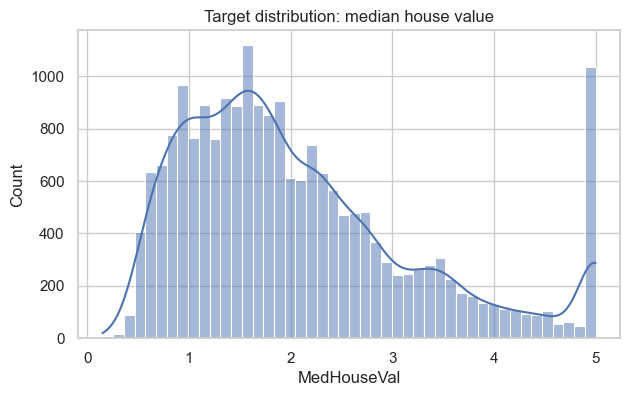

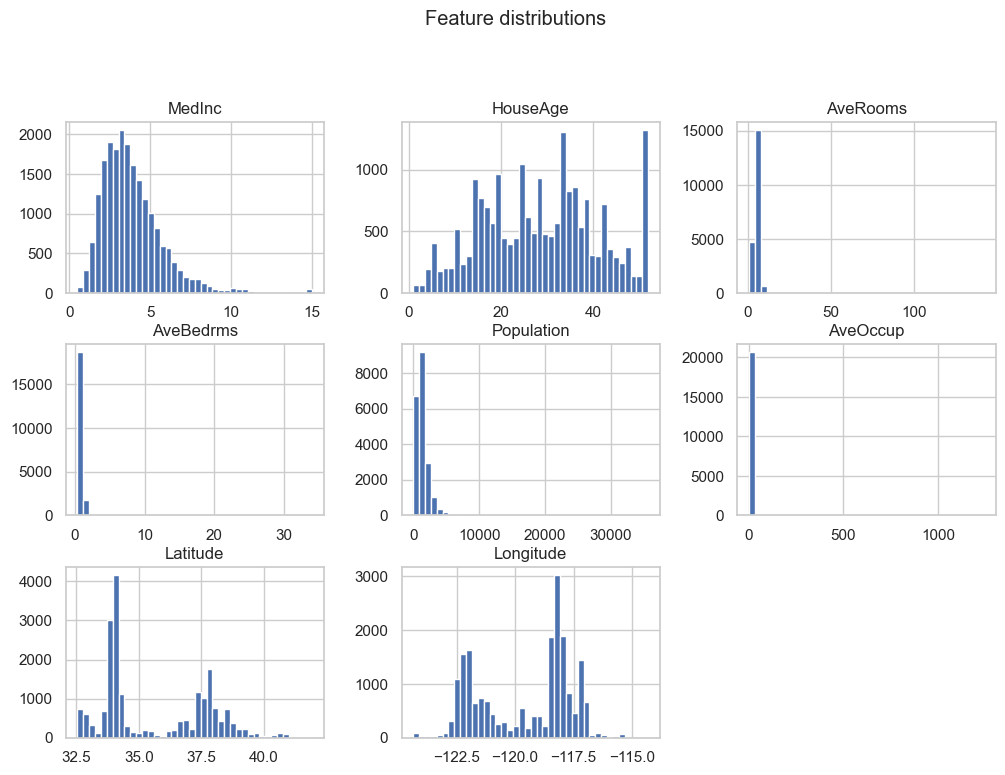

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(y, kde=True, ax=ax)
ax.set_title("Target distribution: median house value")
plt.show()

X.hist(figsize=(12, 8), bins=40)
plt.suptitle("Feature distributions", y=1.02)
plt.show()

### Analytical interpretation

The target distribution should be read together with the feature histograms. Skewed variables and extreme values can make errors uneven across the target range. If the target piles up near its maximum, later residual plots should be checked for under-prediction at the upper end.

The correlation heatmap summarizes linear associations among features and the target. Strong feature-feature correlations are especially relevant for coefficient interpretation and regularized linear models.

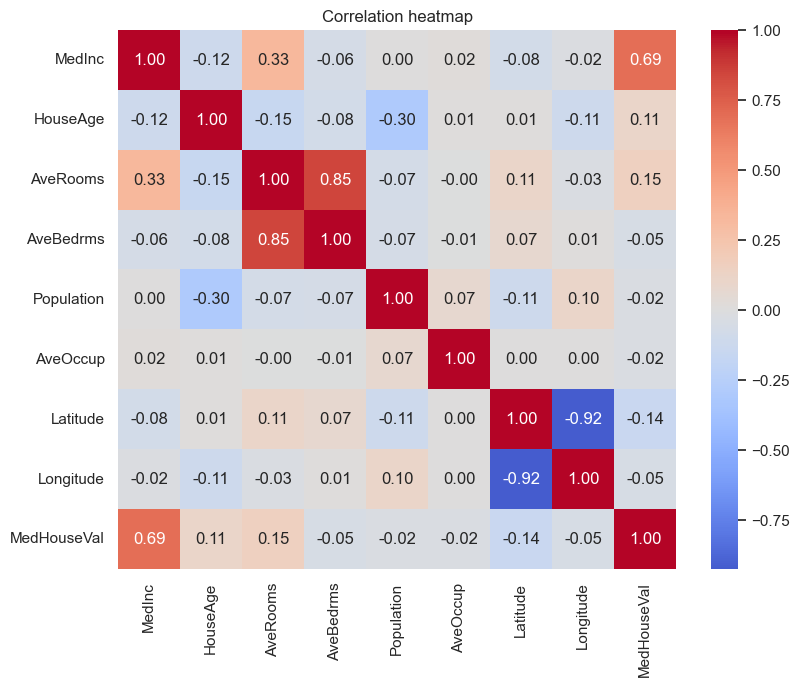

In [4]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

### Analytical interpretation

The heatmap helps identify redundant predictors and strong linear associations. When predictors are correlated, coefficient-based interpretation becomes less direct because multiple variables may share the same explanatory signal.

The scatter plots compare selected predictors with the target. They help reveal whether relationships look linear, nonlinear, noisy, or affected by saturation at the target cap.

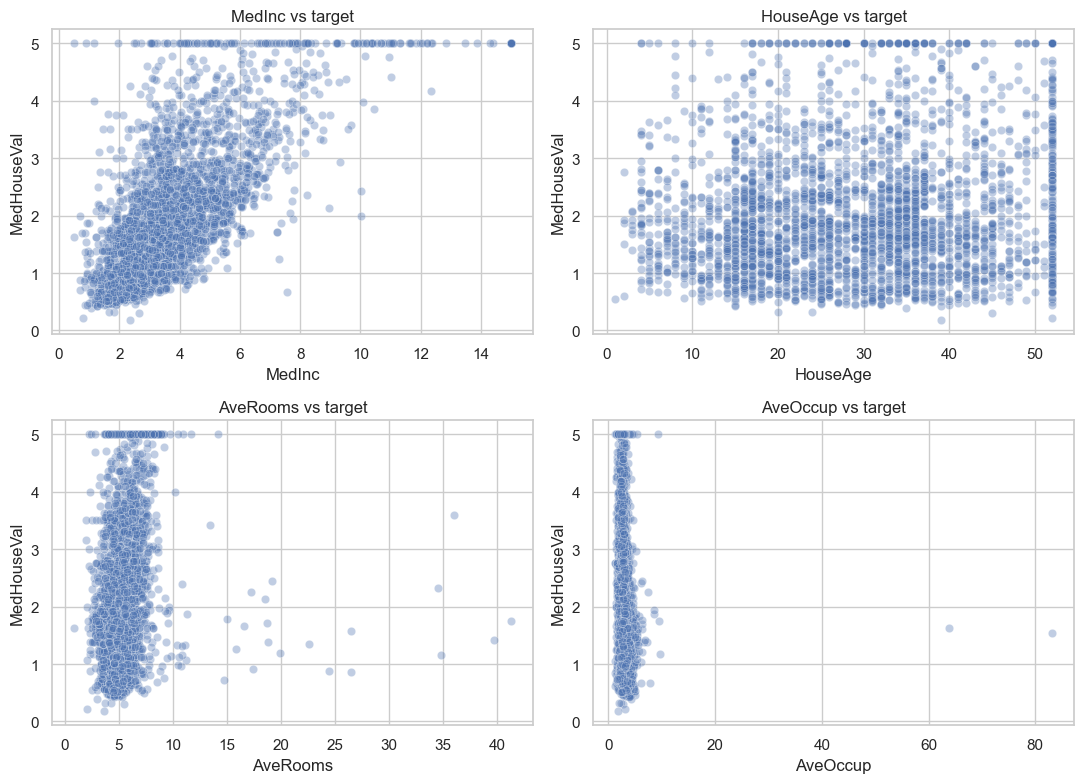

In [5]:
selected = ["MedInc", "HouseAge", "AveRooms", "AveOccup"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), selected):
    sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x=col, y="MedHouseVal", alpha=0.35, ax=ax)
    ax.set_title(f"{col} vs target")
plt.tight_layout()
plt.show()

### Analytical interpretation

These scatter plots usually reveal that no single feature explains the target perfectly. A visible trend with substantial spread suggests that models can learn useful signal, but residual error will remain because the observations are aggregated and noisy.

The location plot checks whether target values have spatial structure. If geography strongly influences the target, a random split may be easier than a spatially separated generalization test.

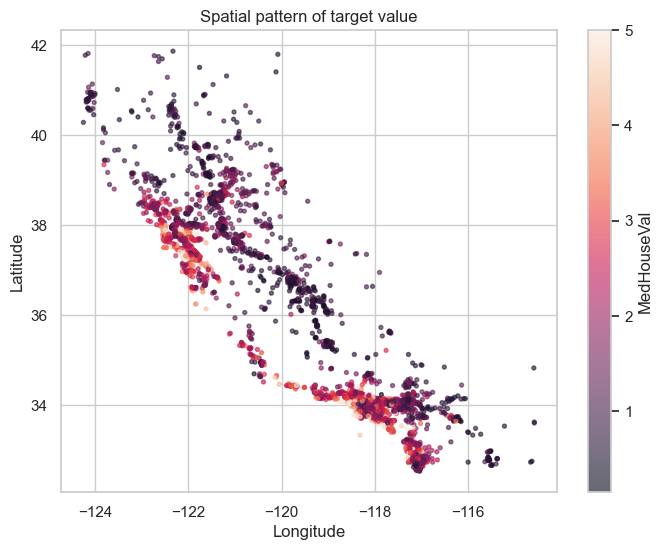

In [6]:
sample = df.sample(6000, random_state=RANDOM_STATE)
plt.figure(figsize=(8, 6))
sc = plt.scatter(sample["Longitude"], sample["Latitude"], c=sample["MedHouseVal"], s=8, alpha=0.6)
plt.colorbar(sc, label="MedHouseVal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial pattern of target value")
plt.show()

### Analytical interpretation

Spatial clustering of target values indicates that geography carries predictive information. This also warns that random splitting may overestimate real deployment performance if nearby locations appear in both training and test sets.

## Train/validation/test split

The test set is kept untouched until final evaluation. Hyperparameter reasoning uses the training and validation sets.

The data are split into separate partitions so that model selection and final evaluation remain distinct. This separation prevents the test set from influencing hyperparameter choices.

In [7]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)
print(X_train.shape, X_val.shape, X_test.shape)

(12384, 8) (4128, 8) (4128, 8)


### Analytical interpretation

The split sizes confirm that training, validation, and testing are separated. The validation set supports model selection, while the final test set should be used only after the modeling decisions are fixed.

Reusable metric functions are defined here so that every model is evaluated consistently. This is important because fair comparison requires the same data split, metrics, and reporting style.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "R2": r2_score(y_true, y_pred),
    }

def evaluate_regressor(name, model, X_train, y_train, X_val, y_val, fit=True):
    start = time.time()
    if fit:
        model.fit(X_train, y_train)
    runtime = time.time() - start
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    row = {"Model": name, "Runtime_sec": runtime}
    for prefix, y_true, y_pred in [("Train", y_train, train_pred), ("Validation", y_val, val_pred)]:
        m = regression_metrics(y_true, y_pred)
        row.update({f"{prefix}_{k}": v for k, v in m.items()})
    return row

## Baseline: Dummy Regressor

A mean predictor is weak, but it tells us the minimum useful level of performance. Any serious model should improve meaningfully over this baseline.

A baseline model anchors the analysis. For regression, the mean predictor ignores all features and estimates every target with the same value. Its purpose is to quantify the error level obtained without learning any relationship. Later models should be compared against this reference before claiming improvement.

The baseline model is fitted before any serious model. Its score defines the minimum level that later models must exceed to demonstrate that they have learned useful structure.

In [9]:
baseline = DummyRegressor(strategy="mean")
baseline_row = evaluate_regressor("Dummy mean", baseline, X_train, y_train, X_val, y_val)
pd.DataFrame([baseline_row])

,Model,Runtime_sec,Train_MAE,Train_RMSE,Train_R2,Validation_MAE,Validation_RMSE,Validation_R2
0,Dummy mean,0.001013,0.909328,1.150915,0.0,0.924793,1.171903,-0.000174


### Analytical interpretation

The dummy regressor should have approximately zero explanatory power. Its role is not prediction quality but calibration of expectations: every useful regression model must reduce RMSE/MAE and improve \(R^2\) relative to this baseline.

## Linear Regression

The linear model is interpretable and fast. Scaling is included so coefficients are easier to compare by magnitude.

Linear regression assumes that the target can be approximated by a weighted sum of the input variables. Each coefficient represents the expected change in the prediction for a one-unit change in that feature, holding other features fixed. After scaling, coefficient magnitudes become easier to compare, but they should still be interpreted cautiously when features are correlated.

A scaled linear-regression pipeline is trained and evaluated. Scaling does not change ordinary least-squares predictions in a simple setting, but it makes coefficient magnitudes easier to compare.

In [10]:
linear_pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
linear_row = evaluate_regressor("Linear Regression", linear_pipe, X_train, y_train, X_val, y_val)
pd.DataFrame([linear_row])

,Model,Runtime_sec,Train_MAE,Train_RMSE,Train_R2,Validation_MAE,Validation_RMSE,Validation_R2
0,Linear Regression,0.02669,0.526649,0.717203,0.611673,0.533335,0.727838,0.6142


### Analytical interpretation

The linear model normally improves over the dummy baseline, which means the features contain real signal. However, remaining residual structure or a moderate validation score indicates that purely additive linear relationships are not sufficient for the full problem.

The learned coefficients are organized by magnitude. This gives an interpretable view of which standardized variables most strongly influence the linear prediction.

,Feature,Coefficient,AbsCoefficient
6,Latitude,-0.888213,0.888213
7,Longitude,-0.861907,0.861907
0,MedInc,0.860253,0.860253
3,AveBedrms,0.312087,0.312087
2,AveRooms,-0.280392,0.280392
1,HouseAge,0.120007,0.120007
5,AveOccup,-0.026158,0.026158
4,Population,-0.009574,0.009574


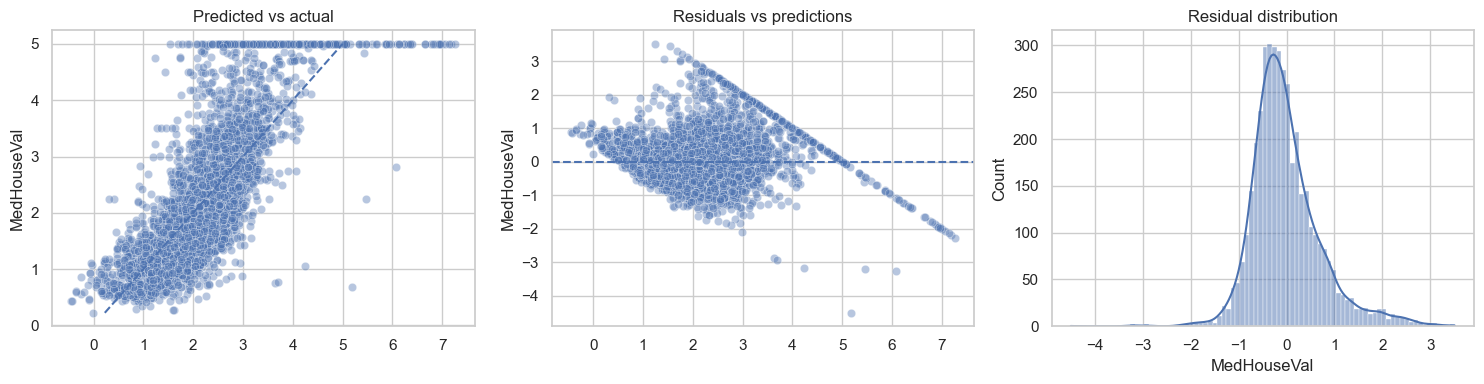

In [11]:
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": linear_pipe.named_steps["model"].coef_})
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
display(coef_df.sort_values("AbsCoefficient", ascending=False))

val_pred = linear_pipe.predict(X_val)
residuals = y_val - val_pred
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x=val_pred, y=y_val, alpha=0.4, ax=axes[0])
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], linestyle="--")
axes[0].set_title("Predicted vs actual")
sns.scatterplot(x=val_pred, y=residuals, alpha=0.4, ax=axes[1])
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals vs predictions")
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title("Residual distribution")
plt.tight_layout(); plt.show()

### Analytical interpretation

Large standardized coefficients indicate features that strongly influence the linear prediction, but they should not be read as causal effects. Correlated predictors can redistribute coefficient weight, and omitted variables can also distort interpretation.

### Interpretation guide

After running the residual plots, check whether errors are centered around zero, whether residual spread changes with prediction magnitude, and whether the linear model systematically misses high-value or low-value regions.

## Polynomial Regression: degree effect

Polynomial features can model nonlinear relationships, but feature count grows quickly. To keep the experiment interpretable and fast, this section uses a limited subset of informative numerical features.

Polynomial degree is varied manually to observe how increasing nonlinear flexibility changes training and validation error. The goal is to identify underfitting and overfitting rather than blindly selecting a degree.

,Degree,Num_features_after_poly,Train_RMSE,Validation_RMSE,Train_R2,Validation_R2
0,1,4,0.799395,0.818003,0.517568,0.512693
1,2,14,0.755245,3.127209,0.569385,-6.122075
2,3,34,0.716671,3.617224,0.612249,-8.528915
3,4,69,0.702154,36.701224,0.627798,-979.965707


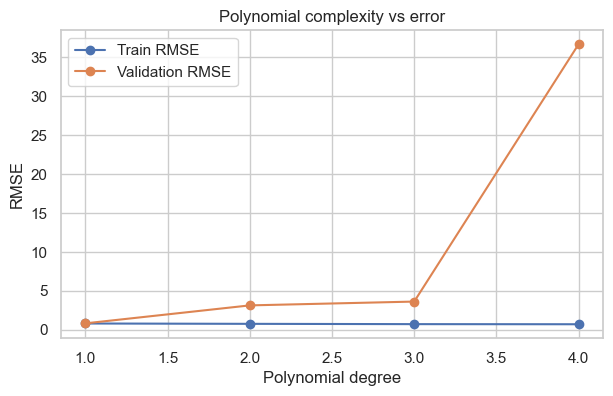

In [12]:
poly_features = ["MedInc", "HouseAge", "AveRooms", "AveOccup"]
degrees = [1, 2, 3, 4]
poly_rows = []
for d in degrees:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])
    row = evaluate_regressor(f"Polynomial degree {d}", pipe, X_train[poly_features], y_train, X_val[poly_features], y_val)
    row["Degree"] = d
    row["Num_features_after_poly"] = pipe.named_steps["poly"].n_output_features_
    poly_rows.append(row)
poly_df = pd.DataFrame(poly_rows)
display(poly_df[["Degree", "Num_features_after_poly", "Train_RMSE", "Validation_RMSE", "Train_R2", "Validation_R2"]])

plt.figure(figsize=(7,4))
plt.plot(poly_df["Degree"], poly_df["Train_RMSE"], marker="o", label="Train RMSE")
plt.plot(poly_df["Degree"], poly_df["Validation_RMSE"], marker="o", label="Validation RMSE")
plt.xlabel("Polynomial degree")
plt.ylabel("RMSE")
plt.title("Polynomial complexity vs error")
plt.legend(); plt.show()

### Analytical interpretation

The degree comparison should be read as a bias-variance experiment. A lower degree may underfit both training and validation data, while a higher degree can reduce training error but worsen validation error. The most useful degree is usually where validation error is low and the train-validation gap remains controlled.

### Interpretation guide

Compare training and validation RMSE. If training error decreases while validation error stops improving or worsens, the polynomial expansion is adding variance rather than useful generalization.

## Ridge Regression: alpha effect

Ridge shrinks coefficients using an L2 penalty. Larger `alpha` usually reduces coefficient magnitude and variance, but excessive shrinkage can underfit.

Ridge models are trained across several `alpha` values. The experiment shows how stronger L2 regularization changes validation error and shrinks coefficient magnitudes.

,Alpha,Train_RMSE,Validation_RMSE,Train_R2,Validation_R2,Coef_L2_norm
0,0.001,0.717203,0.727838,0.611673,0.614200,1.569406
1,0.010,0.717203,0.727838,0.611673,0.614200,1.569394
2,0.100,0.717203,0.727837,0.611673,0.614201,1.569281
3,1.000,0.717203,0.727830,0.611673,0.614208,1.568149
4,10.000,0.717213,0.727771,0.611662,0.614271,1.556973
5,100.000,0.718101,0.728029,0.610700,0.613997,1.458050


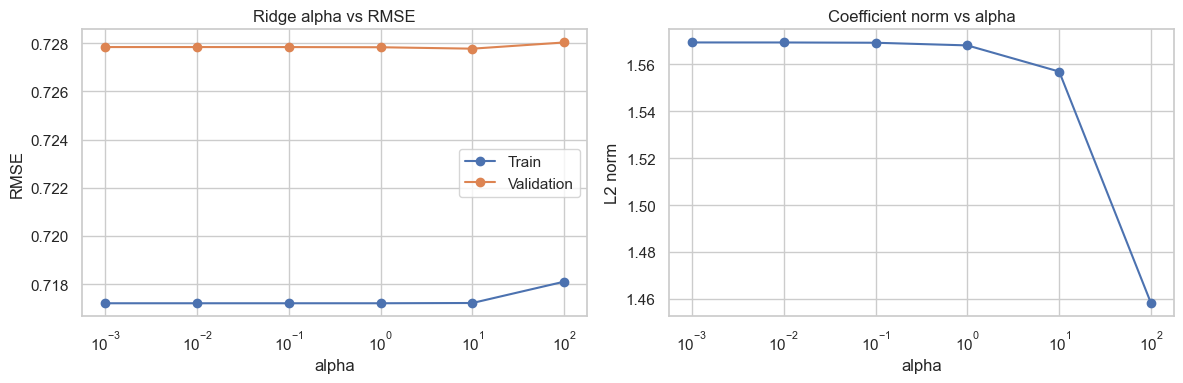

In [13]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_rows, ridge_coefs = [], []
for a in alphas:
    pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=a))])
    row = evaluate_regressor(f"Ridge alpha={a}", pipe, X_train, y_train, X_val, y_val)
    row["Alpha"] = a
    row["Coef_L2_norm"] = np.linalg.norm(pipe.named_steps["model"].coef_)
    ridge_rows.append(row)
    ridge_coefs.append(pipe.named_steps["model"].coef_)
ridge_df = pd.DataFrame(ridge_rows)
display(ridge_df[["Alpha", "Train_RMSE", "Validation_RMSE", "Train_R2", "Validation_R2", "Coef_L2_norm"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(ridge_df["Alpha"], ridge_df["Train_RMSE"], marker="o", label="Train")
axes[0].semilogx(ridge_df["Alpha"], ridge_df["Validation_RMSE"], marker="o", label="Validation")
axes[0].set_title("Ridge alpha vs RMSE")
axes[0].set_xlabel("alpha"); axes[0].set_ylabel("RMSE"); axes[0].legend()
axes[1].semilogx(ridge_df["Alpha"], ridge_df["Coef_L2_norm"], marker="o")
axes[1].set_title("Coefficient norm vs alpha")
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("L2 norm")
plt.tight_layout(); plt.show()

### Analytical interpretation

As `alpha` increases, coefficients should shrink and the model becomes smoother. A small increase in validation error may be acceptable if coefficient magnitudes become more stable, but very large `alpha` typically underfits.

## Lasso Regression: sparsity effect

Lasso uses an L1 penalty. It can set some coefficients exactly to zero, which makes it useful for feature selection, but too much penalty can remove useful variables.

Lasso models are trained across several penalties. In addition to predictive performance, the number of nonzero coefficients is tracked to show the feature-selection effect of L1 regularization.

,Alpha,Train_RMSE,Validation_RMSE,Train_R2,Validation_R2,Nonzero_coefficients
0,0.0001,0.717203,0.727803,0.611673,0.614238,8
1,0.0010,0.717237,0.727519,0.611636,0.614538,8
2,0.0100,0.720613,0.728337,0.607972,0.613670,7
3,0.0500,0.776363,0.784879,0.544966,0.551360,4
4,0.1000,0.817245,0.826151,0.495783,0.502937,3
5,0.5000,0.972326,0.985705,0.286264,0.292402,1


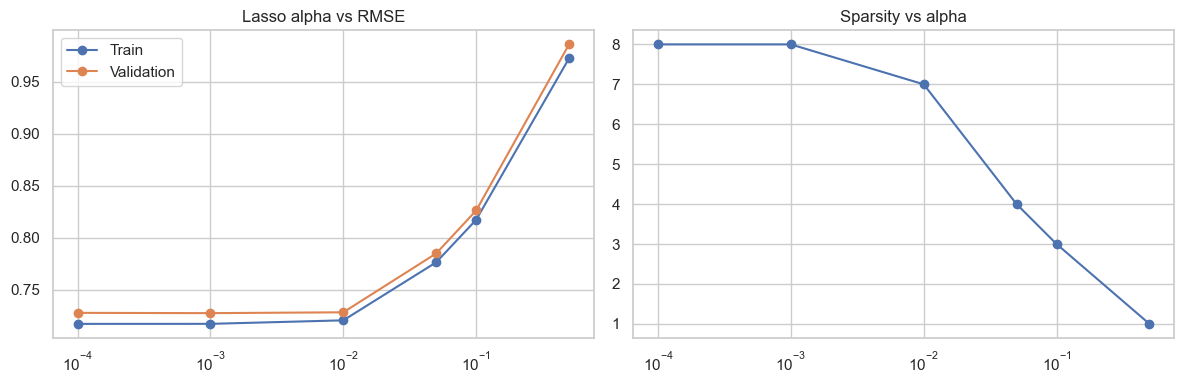

In [14]:
lasso_alphas = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]
lasso_rows = []
for a in lasso_alphas:
    pipe = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=a, max_iter=20000, random_state=RANDOM_STATE))])
    row = evaluate_regressor(f"Lasso alpha={a}", pipe, X_train, y_train, X_val, y_val)
    row["Alpha"] = a
    row["Nonzero_coefficients"] = np.sum(np.abs(pipe.named_steps["model"].coef_) > 1e-8)
    lasso_rows.append(row)
lasso_df = pd.DataFrame(lasso_rows)
display(lasso_df[["Alpha", "Train_RMSE", "Validation_RMSE", "Train_R2", "Validation_R2", "Nonzero_coefficients"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(lasso_df["Alpha"], lasso_df["Train_RMSE"], marker="o", label="Train")
axes[0].semilogx(lasso_df["Alpha"], lasso_df["Validation_RMSE"], marker="o", label="Validation")
axes[0].set_title("Lasso alpha vs RMSE"); axes[0].legend()
axes[1].semilogx(lasso_df["Alpha"], lasso_df["Nonzero_coefficients"], marker="o")
axes[1].set_title("Sparsity vs alpha")
plt.tight_layout(); plt.show()

### Analytical interpretation

The Lasso results should be interpreted using both validation error and the number of nonzero coefficients. If many coefficients vanish with little loss in validation performance, the model has found a simpler sparse representation. If performance drops sharply, the penalty is too strong.

## ElasticNet: combining L1 and L2

ElasticNet is useful when we want both shrinkage and some sparsity. `l1_ratio=0` behaves like Ridge, while `l1_ratio=1` behaves like Lasso.

ElasticNet is compared with Ridge and Lasso to show the effect of combining L1 and L2 penalties. This is useful when predictors are correlated but some sparsity is still desirable.

In [15]:
elastic_rows = []
for l1 in [0.1, 0.5, 0.9]:
    pipe = Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=0.01, l1_ratio=l1, max_iter=20000, random_state=RANDOM_STATE))])
    row = evaluate_regressor(f"ElasticNet l1_ratio={l1}", pipe, X_train, y_train, X_val, y_val)
    row["l1_ratio"] = l1
    row["Nonzero_coefficients"] = np.sum(np.abs(pipe.named_steps["model"].coef_) > 1e-8)
    elastic_rows.append(row)
elastic_df = pd.DataFrame(elastic_rows)
display(elastic_df[["l1_ratio", "Train_RMSE", "Validation_RMSE", "Validation_R2", "Nonzero_coefficients"]])

,l1_ratio,Train_RMSE,Validation_RMSE,Validation_R2,Nonzero_coefficients
0,0.1,0.718637,0.728183,0.613834,8
1,0.5,0.719306,0.727951,0.614080,8
2,0.9,0.720306,0.728191,0.613825,7


### Analytical interpretation

ElasticNet is useful when Ridge is too dense and Lasso is too aggressive. Compare whether it keeps validation performance close to the best regularized model while producing a more controlled coefficient pattern.

## Decision Tree Regressor: depth and leaf-size effects

A tree can model nonlinear interactions without scaling. However, deep trees can memorize training data. `max_depth` and `min_samples_leaf` are direct complexity controls.

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

,max_depth,Train_RMSE,Validation_RMSE,Train_R2,Validation_R2
0,2,8.531696e-01,0.865775,0.450479,0.454113
1,4,7.341555e-01,0.757239,0.593098,0.582402
2,6,6.415041e-01,0.679776,0.689321,0.663469
3,8,5.511692e-01,0.640647,0.770658,0.701097
4,10,4.425954e-01,0.637475,0.852114,0.704049
5,None,2.913981e-16,0.706117,1.000000,0.636884


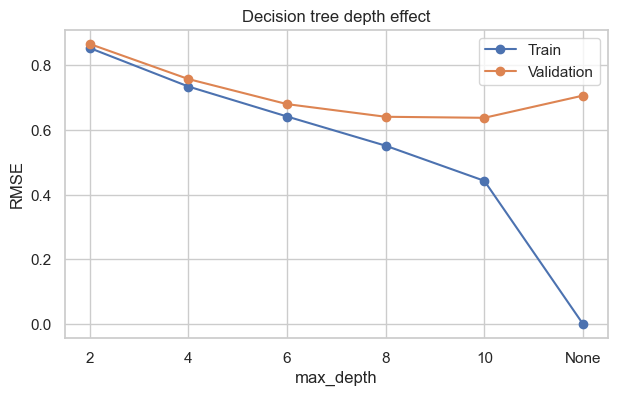

In [16]:
depth_values = [2, 4, 6, 8, 10, None]
tree_depth_rows = []
for depth in depth_values:
    model = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    row = evaluate_regressor(f"Tree depth={depth}", model, X_train, y_train, X_val, y_val)
    row["max_depth"] = str(depth)
    tree_depth_rows.append(row)
tree_depth_df = pd.DataFrame(tree_depth_rows)
display(tree_depth_df[["max_depth", "Train_RMSE", "Validation_RMSE", "Train_R2", "Validation_R2"]])

plt.figure(figsize=(7, 4))
plt.plot(tree_depth_df["max_depth"], tree_depth_df["Train_RMSE"], marker="o", label="Train")
plt.plot(tree_depth_df["max_depth"], tree_depth_df["Validation_RMSE"], marker="o", label="Validation")
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("Decision tree depth effect")
plt.legend(); plt.show()

### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

In [17]:
leaf_values = [1, 5, 10, 30, 50]
tree_leaf_rows = []
for leaf in leaf_values:
    model = DecisionTreeRegressor(max_depth=None, min_samples_leaf=leaf, random_state=RANDOM_STATE)
    row = evaluate_regressor(f"Tree leaf={leaf}", model, X_train, y_train, X_val, y_val)
    row["min_samples_leaf"] = leaf
    tree_leaf_rows.append(row)
tree_leaf_df = pd.DataFrame(tree_leaf_rows)
display(tree_leaf_df[["min_samples_leaf", "Train_RMSE", "Validation_RMSE", "Train_R2", "Validation_R2"]])

,min_samples_leaf,Train_RMSE,Validation_RMSE,Train_R2,Validation_R2
0,1,2.913981e-16,0.706117,1.000000,0.636884
1,5,3.509479e-01,0.629374,0.907018,0.711524
2,10,4.375942e-01,0.619643,0.855437,0.720375
3,30,5.357993e-01,0.612637,0.783271,0.726663
4,50,5.687181e-01,0.621327,0.755821,0.718853


### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Random Forest Regressor: bagging and feature randomness

Random forests average many noisy trees. More trees often stabilize predictions, while depth and leaf size still control individual-tree complexity.

Random Forest settings are varied to study variance reduction, tree complexity, and runtime. The important pattern is whether performance stabilizes as more trees are added.

,n_estimators,Runtime_sec,Train_RMSE,Validation_RMSE,Train_R2,Validation_R2
0,10,1.616406,0.230779,0.538164,0.959793,0.789078
1,50,6.430949,0.194943,0.513536,0.971310,0.807941
2,100,13.688753,0.190709,0.509735,0.972543,0.810774
3,200,26.376593,0.188142,0.508785,0.973277,0.811478


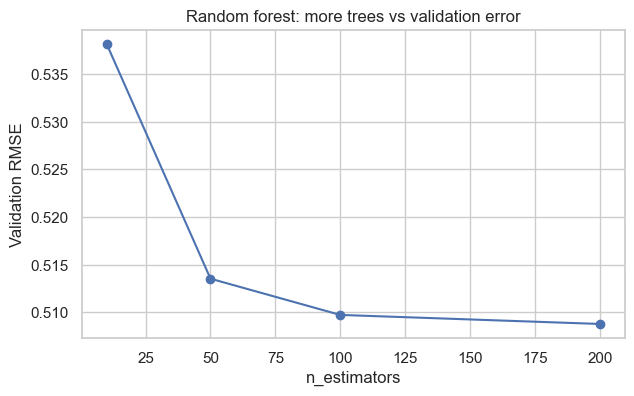

In [18]:
rf_rows = []
for n in [10, 50, 100, 200]:
    model = RandomForestRegressor(n_estimators=n, max_depth=None, min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1)
    row = evaluate_regressor(f"RF n_estimators={n}", model, X_train, y_train, X_val, y_val)
    row["n_estimators"] = n
    rf_rows.append(row)
rf_df = pd.DataFrame(rf_rows)
display(rf_df[["n_estimators", "Runtime_sec", "Train_RMSE", "Validation_RMSE", "Train_R2", "Validation_R2"]])
plt.figure(figsize=(7,4))
plt.plot(rf_df["n_estimators"], rf_df["Validation_RMSE"], marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Validation RMSE")
plt.title("Random forest: more trees vs validation error")
plt.show()

### Analytical interpretation

Random Forest performance usually improves quickly as trees are added and then stabilizes. A plateau means that adding more trees mainly increases computation. Depth and leaf-size results indicate how much complexity each individual tree should be allowed.

Random Forest settings are varied to study variance reduction, tree complexity, and runtime. The important pattern is whether performance stabilizes as more trees are added.

,max_depth,Train_RMSE,Validation_RMSE,Train_R2,Validation_R2
0,5,0.642162,0.669689,0.688683,0.673383
1,10,0.397399,0.536622,0.880775,0.790285
2,20,0.194371,0.509254,0.971478,0.811131
3,None,0.190709,0.509735,0.972543,0.810774


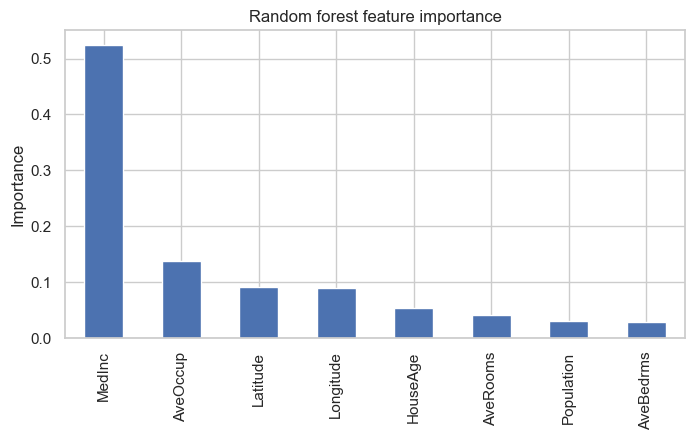

In [19]:
rf_depth_rows = []
for depth in [5, 10, 20, None]:
    model = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=RANDOM_STATE, n_jobs=-1)
    row = evaluate_regressor(f"RF depth={depth}", model, X_train, y_train, X_val, y_val)
    row["max_depth"] = str(depth)
    rf_depth_rows.append(row)
rf_depth_df = pd.DataFrame(rf_depth_rows)
display(rf_depth_df[["max_depth", "Train_RMSE", "Validation_RMSE", "Train_R2", "Validation_R2"]])

best_rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.plot(kind="bar", figsize=(8, 4), title="Random forest feature importance")
plt.ylabel("Importance"); plt.show()

### Analytical interpretation

Random Forest performance usually improves quickly as trees are added and then stabilizes. A plateau means that adding more trees mainly increases computation. Depth and leaf-size results indicate how much complexity each individual tree should be allowed.

## Gradient Boosting Regressor: learning-rate / estimator tradeoff

Boosting builds trees sequentially. A small learning rate usually needs more trees; a large learning rate can fit quickly but may be less stable.

Gradient Boosting settings are varied to study the trade-off between learning rate, number of estimators, and tree depth. This shows how sequential error correction can improve performance but also overfit.

,learning_rate,n_estimators,Train_RMSE,Validation_RMSE,Train_R2,Validation_R2,Runtime_sec
11,0.20,200,0.412671,0.487845,0.871435,0.826677,20.433322
10,0.20,100,0.460279,0.503916,0.840061,0.815069,11.518486
8,0.10,200,0.459515,0.507254,0.840591,0.812611,15.251487
7,0.10,100,0.501314,0.531367,0.810272,0.794372,7.490746
9,0.20,50,0.507244,0.533711,0.805756,0.792554,3.835035
5,0.05,200,0.504715,0.534973,0.807688,0.791572,15.866927
2,0.03,200,0.540984,0.564341,0.779056,0.768060,18.023996
4,0.05,100,0.552006,0.574013,0.769961,0.760042,8.987840
6,0.10,50,0.552889,0.575196,0.769225,0.759052,4.674087
1,0.03,100,0.613855,0.634498,0.715524,0.706807,8.656848


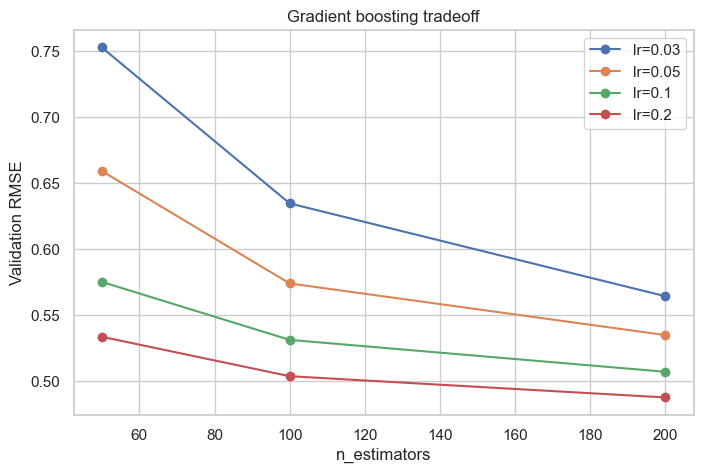

In [20]:
gb_rows = []
for lr in [0.03, 0.05, 0.1, 0.2]:
    for n in [50, 100, 200]:
        model = GradientBoostingRegressor(learning_rate=lr, n_estimators=n, max_depth=3, random_state=RANDOM_STATE)
        row = evaluate_regressor(f"GB lr={lr}, n={n}", model, X_train, y_train, X_val, y_val)
        row["learning_rate"] = lr
        row["n_estimators"] = n
        gb_rows.append(row)
gb_df = pd.DataFrame(gb_rows)
display(gb_df.sort_values("Validation_RMSE")[["learning_rate", "n_estimators", "Train_RMSE", "Validation_RMSE", "Train_R2", "Validation_R2", "Runtime_sec"]].head(12))

plt.figure(figsize=(8, 5))
for lr, sub in gb_df.groupby("learning_rate"):
    plt.plot(sub["n_estimators"], sub["Validation_RMSE"], marker="o", label=f"lr={lr}")
plt.xlabel("n_estimators")
plt.ylabel("Validation RMSE")
plt.title("Gradient boosting tradeoff")
plt.legend(); plt.show()

### Analytical interpretation

Boosting results should be read through the learning-rate/estimator trade-off. Strong validation performance with controlled depth suggests useful sequential error correction; a growing train-validation gap suggests the ensemble is beginning to chase noise.

### Interpretation guide

Look for combinations where validation error improves without a large gap between train and validation performance. Do not choose a setting only because it has the smallest training error.

## Final model comparison on the test set

Only after selecting reasonable candidates from validation behavior do we evaluate on the test set.

The baseline model is fitted before any serious model. Its score defines the minimum level that later models must exceed to demonstrate that they have learned useful structure.

In [21]:
candidate_models = {
    "Dummy mean": DummyRegressor(strategy="mean"),
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge alpha=1": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Lasso alpha=0.001": Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.001, max_iter=20000, random_state=RANDOM_STATE))]),
    "Decision Tree depth=8": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(learning_rate=0.1, n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
}
comparison = []
for name, model in candidate_models.items():
    start = time.time()
    model.fit(X_train, y_train)
    runtime = time.time() - start
    pred = model.predict(X_test)
    row = {"Model": name, "Runtime_sec": runtime}
    row.update(regression_metrics(y_test, pred))
    comparison.append(row)
comparison_df = pd.DataFrame(comparison).sort_values("RMSE")
display(comparison_df)

,Model,Runtime_sec,MAE,RMSE,R2
5,Random Forest,17.087116,0.331772,0.509319,0.802042
6,Gradient Boosting,29.226782,0.348756,0.512263,0.799747
4,Decision Tree depth=8,0.206365,0.450165,0.653582,0.674018
3,Lasso alpha=0.001,0.194181,0.533150,0.748420,0.572551
2,Ridge alpha=1,0.007971,0.533290,0.749487,0.571332
1,Linear Regression,0.013534,0.533302,0.749527,0.571286
0,Dummy mean,0.001058,0.905296,1.144806,-0.000130


### Analytical interpretation

The dummy regressor should have approximately zero explanatory power. Its role is not prediction quality but calibration of expectations: every useful regression model must reduce RMSE/MAE and improve \(R^2\) relative to this baseline.

## Residual and error analysis for the best few models

The best model by RMSE is not automatically the best model for every objective. Residual plots can reveal systematic failures.

Residual plots are used to diagnose model behavior beyond a single error number. Patterns in residuals indicate bias, heteroscedasticity, or regions where the model systematically under- or over-predicts.

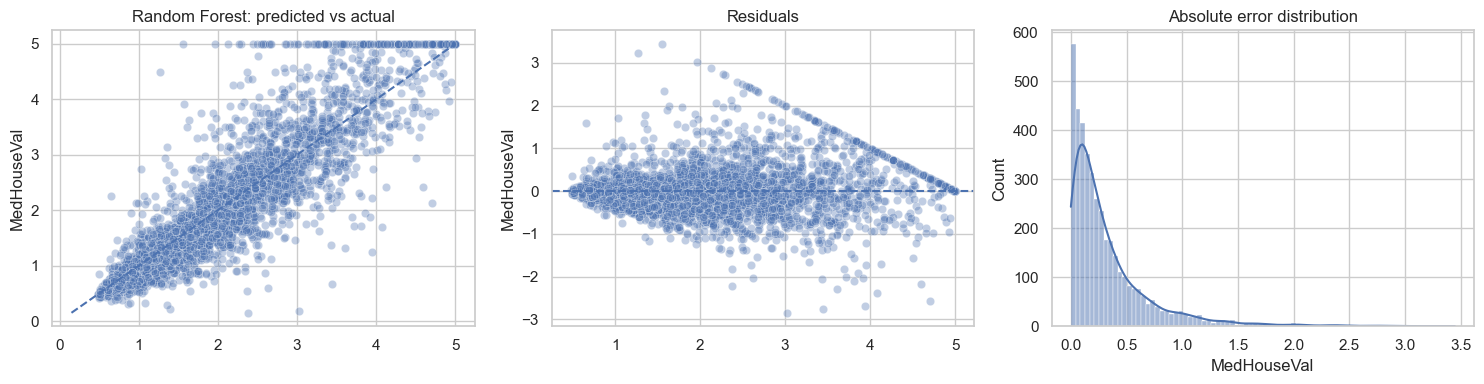

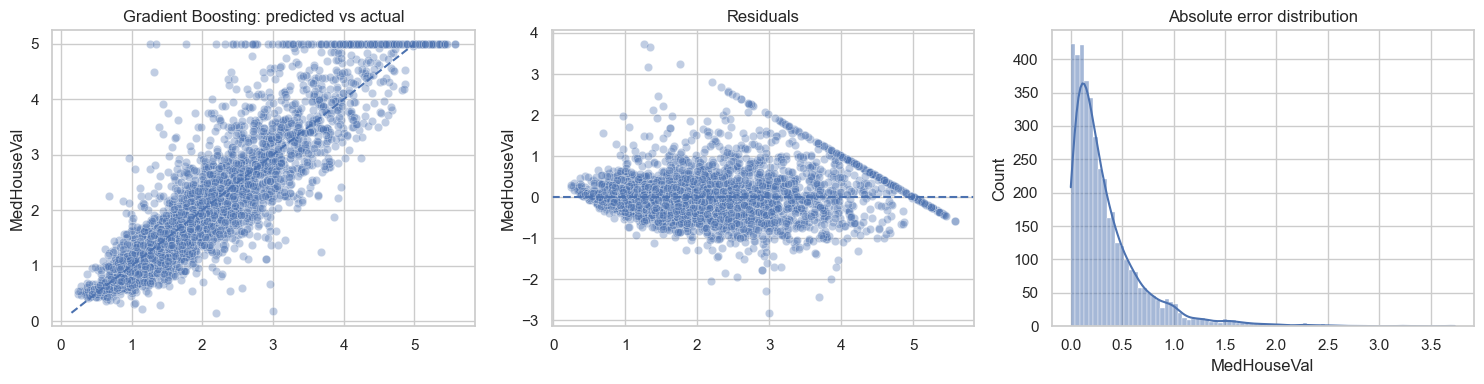

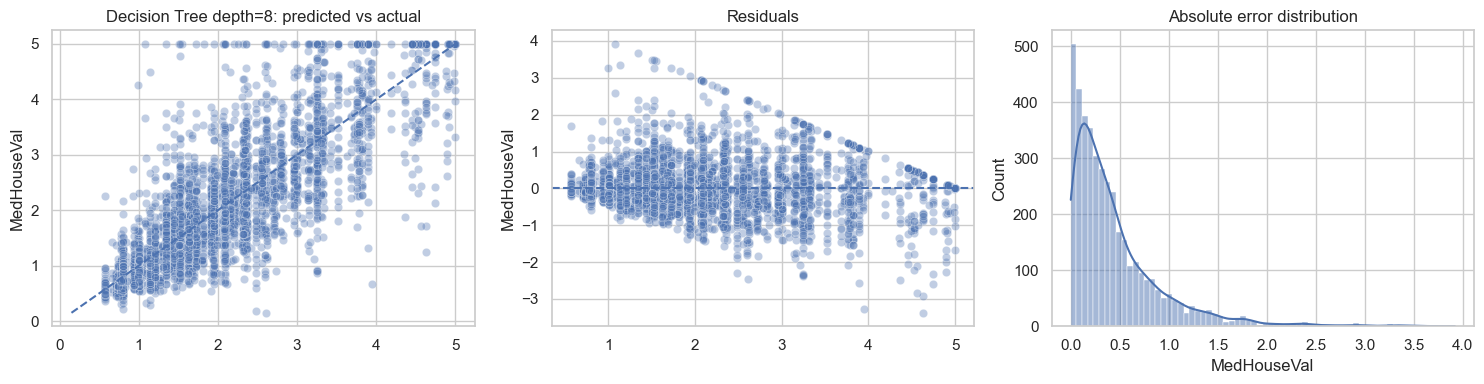

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,actual,predicted,abs_error
459,1.1696,52.0,2.436000,0.944000,1349.0,5.396000,37.87,-122.25,5.00001,1.554750,3.445260
19542,1.7679,39.0,5.000000,0.888889,22.0,2.444444,37.63,-120.92,4.50000,1.267590,3.232410
12069,4.2386,6.0,7.723077,1.169231,228.0,3.507692,33.83,-117.55,5.00001,1.968370,3.031640
12220,5.2066,4.0,10.500000,1.445652,311.0,3.380435,33.51,-117.32,5.00001,2.124260,2.875750
5887,2.3667,39.0,3.572464,1.217391,259.0,1.876812,34.15,-118.33,0.17500,3.020951,2.845951
4548,7.5752,52.0,3.142857,1.000000,55.0,7.857143,34.02,-118.21,0.67500,3.442871,2.767871
20325,4.5833,21.0,7.278431,1.082353,863.0,3.384314,34.28,-119.04,5.00001,2.269190,2.730820
17306,2.7275,17.0,5.574286,1.051429,681.0,1.945714,34.38,-119.55,5.00001,2.289420,2.710590
20349,7.3004,32.0,5.724138,0.758621,63.0,2.172414,34.17,-119.08,1.25000,3.943302,2.693302
12389,3.7727,24.0,10.953586,1.848101,473.0,1.995781,33.75,-116.43,5.00001,2.437191,2.562819


In [22]:
top_names = comparison_df["Model"].head(3).tolist()
for name in top_names:
    model = candidate_models[name]
    pred = model.predict(X_test)
    residuals = y_test - pred
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.scatterplot(x=pred, y=y_test, alpha=0.35, ax=axes[0])
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
    axes[0].set_title(f"{name}: predicted vs actual")
    sns.scatterplot(x=pred, y=residuals, alpha=0.35, ax=axes[1])
    axes[1].axhline(0, linestyle="--")
    axes[1].set_title("Residuals")
    sns.histplot(np.abs(residuals), kde=True, ax=axes[2])
    axes[2].set_title("Absolute error distribution")
    plt.tight_layout(); plt.show()

# Inspect high-error examples for the best model
best_name = comparison_df.iloc[0]["Model"]
best_model = candidate_models[best_name]
best_pred = best_model.predict(X_test)
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = best_pred
error_df["abs_error"] = np.abs(error_df["actual"] - error_df["predicted"])
display(error_df.sort_values("abs_error", ascending=False).head(10))

### Analytical interpretation

Residual plots reveal whether errors are randomly scattered or systematic. Curvature, funnel-shaped spread, or strong errors near the target cap suggest that the model is missing nonlinear structure or that the data-generating process is not fully represented by the selected features.

## Additional analytical experiment: target capping and geographic generalization

The final comparison above uses a random split. California Housing has two practical complications: the target is capped at the upper value, and nearby locations are correlated. The following experiment checks whether high-value capped observations are harder to predict and whether a simple geography-based holdout changes performance. This adds a more realistic interpretation layer beyond random-split accuracy.

Best model used: Random Forest


,count,mean,median,max
target_capped,,,,
False,3944,0.310985,0.203270,3.23241
True,184,0.777330,0.515065,3.44526


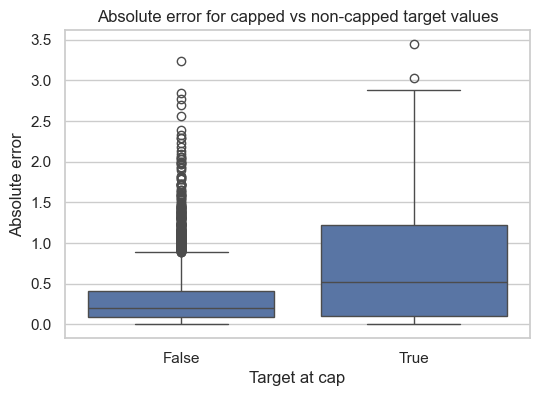

,Model,Geo_holdout_RMSE,Geo_holdout_R2,Train_size,Geo_test_size
0,Ridge alpha=1,0.729937,0.389247,16498,4142
1,Random Forest,1.070535,-0.313700,16498,4142
2,Gradient Boosting,1.074907,-0.324454,16498,4142


In [23]:
# Analyze whether capped high-value targets have larger prediction errors.
best_model_name = comparison_df.iloc[0]["Model"]
best_model = candidate_models[best_model_name]
best_model.fit(X_train, y_train)
y_test_pred = best_model.predict(X_test)
error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_pred"] = y_test_pred
error_df["abs_error"] = np.abs(error_df["y_true"] - error_df["y_pred"])
cap_value = float(y.max())
error_df["target_capped"] = error_df["y_true"] >= cap_value - 1e-5

print("Best model used:", best_model_name)
display(error_df.groupby("target_capped")["abs_error"].agg(["count", "mean", "median", "max"]))

plt.figure(figsize=(6,4))
sns.boxplot(data=error_df, x="target_capped", y="abs_error")
plt.title("Absolute error for capped vs non-capped target values")
plt.xlabel("Target at cap")
plt.ylabel("Absolute error")
plt.show()

# Simple geography-aware split: hold out the northernmost 20% of samples.
lat_cut = X["Latitude"].quantile(0.80)
geo_train_mask = X["Latitude"] < lat_cut
geo_test_mask = ~geo_train_mask
X_geo_train, y_geo_train = X.loc[geo_train_mask], y.loc[geo_train_mask]
X_geo_test, y_geo_test = X.loc[geo_test_mask], y.loc[geo_test_mask]

geo_models = {
    "Ridge alpha=1": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.2, max_depth=3, random_state=RANDOM_STATE),
}
geo_rows = []
for name, model in geo_models.items():
    model.fit(X_geo_train, y_geo_train)
    pred = model.predict(X_geo_test)
    geo_rows.append({
        "Model": name,
        "Geo_holdout_RMSE": mean_squared_error(y_geo_test, pred, squared=False),
        "Geo_holdout_R2": r2_score(y_geo_test, pred),
        "Train_size": len(X_geo_train),
        "Geo_test_size": len(X_geo_test)
    })
geo_df = pd.DataFrame(geo_rows).sort_values("Geo_holdout_RMSE")
display(geo_df)


### How to interpret this added experiment
If capped targets have larger errors, the model is partly limited by the target construction rather than only by algorithm choice. If geography-aware holdout performance is weaker than random-split performance, it suggests spatial correlation: nearby regions help each other in random splits, but transfer to a different latitude band is harder. This is expected in housing data and is a useful caution for real spatial ML problems.

## Interpretation

Compare linear, regularized, polynomial, tree-based, bagging, and boosting models in terms of validation/test performance, residual patterns, interpretability, and runtime. Higher accuracy is useful only when the error behavior is acceptable for the problem.

## Limitations

- The dataset is aggregated at block-group level, not individual house level.
- The target may be capped, making very high-value prediction difficult.
- There is no temporal information.
- Geographic correlation may make random splits optimistic.
- Predictive accuracy does not imply causal understanding.

## What we learned

This project covered baselines, linear regression, regularization, polynomial complexity, decision trees, random forests, gradient boosting, residual analysis, and the bias-variance tradeoff in regression.

## Possible extensions

Try spatial validation, XGBoost/LightGBM regression, quantile regression, prediction intervals, SHAP explanations, and uncertainty estimation.